# Génération de Motifs Quantiques — FRQI

Imaginez et concevez des circuits FRQI qui génèrent des motifs visuels — saurez-vous par exemple créer un circuit de seulement quelques portes capable de produire un damier ?

Le but de ce défi est de créer de beaux motifs quantiques sous forme d'image, en utilisant l'encodage **FRQI** ($\lceil \log_2(N) \rceil + 1$ qubits au lieu de $N$).

> **Règle importante :**
- Pour les motifs réguliers simples (**bruit, damier, bandes**), on attend des **circuits malins** qui exploitent directement les bits d'adresse.
- Pour les motifs plus complexes (**rectangles, niveaux de gris, fractales**), un encodage **adresse par adresse** (`MCX` / `MCRY`) est attendu.

### Partie 1 : Reproduction de Motifs
Nous vous proposons des motifs cibles. Votre objectif est de trouver le circuit FRQI capable de les produire :
1. **Bruit aléatoire** - Neige télévisuelle.
2. **Damier Quantique** - Motif alterné.
3. **Lignes horizontales et verticales** (déterministes).
4. **Rectangles Concentriques** - Carrés imbriqués.
5. **Rectangles en niveaux de gris** - Du centre vers l'extérieur.
6. **Fractales Quantiques** *(bonus)* - Motifs auto-similaires.


In [ ]:
import math
from qiskit import QuantumCircuit
import numpy as np
import matplotlib.pyplot as plt
import importlib

# Import utility functions
import utils_quantum
importlib.reload(utils_quantum)
from utils_quantum import run_simulation
from utils_images import display_image

## Motif 1 - Bruit aléatoire
Vous devez produire une image entièrement aléatoire, comme une neige télévisuelle. Chaque pixel est tiré indépendamment des autres, avec 50 % de chance d’être noir et 50 % de chance d’être blanc.

![random_pattern.png](images/random_noise.png)

Visualisez ensuite quatre reconstructions indépendantes côte à côte, comme dans l’illustration

In [2]:
# todo 

## Motif 2 - Damier Quantique (Quantum Checkerboard) - Motif alterné.

Créer un motif de damier classique (alternance de pixels noirs et blancs). Le circuit est **déterministe** : il produit toujours le même damier.

**2 :** Pouvez-vous aussi trouver comment obtenir le négatif à partir de ce premier circuit ?

![chess](images/chess.png)

Note : le damier et son négatif sont reconstruits séparément, à partir de circuits distincts.

In [3]:
# todo

## Motif 3 - Lignes horizontales (déterministe)
Le motif est toujours le même à chaque exécution : lignes alternées noir/blanc. Pas d'aléatoire !

![Lignes horizontales](images/frqi_bar_horiz.png)

In [4]:
# todo

## Motif 4 - Lignes verticales (déterministe)
Même principe, mais vertical. Le motif est toujours identique.

![Lignes verticales](images/frqi_bar_ver.png)

In [5]:
# todo

## Motif 5 - Rectangles Concentriques — Carrés imbriqués

> **Important :** ce motif est différent du damier et des bandes.
Ici, on attend une approche adresse par adresse.
Autrement dit, il faut traiter chaque pixel individuellement.

Ici, on veut construire des rectangles concentriques, c’est-à-dire des carrés imbriqués qui alternent noir et blanc de l’extérieur vers l’intérieur.

Pour décrire ce motif, on note une image de taille $R \times C$ :
- $R$ = nombre de lignes
- $C$ = nombre de colonnes

Pour un pixel situé à la ligne $r$ et à la colonne $c$, on définit sa **couche** $L(r,c)$ comme sa distance au bord le plus proche :

$$
L(r,c) = \min(r, c, R-1-r, C-1-c)
$$

Ainsi :
- la couche $0$ correspond au bord extérieur,
- la couche $1$ au premier rectangle intérieur,
- la couche $2$ au suivant,
- et ainsi de suite jusqu’au centre.

**Votre objectif :** trouver un circuit FRQI qui reproduit ce motif en respectant cette alternance noir/blanc.


![Rectangles concentriques](images/frqi_carre.png)


In [ ]:
# todo image 10x10 : black / white / black / white / black

## Motif 6 - Rectangles en niveaux de gris — Du centre vers l'extérieur

Même idée que les rectangles concentriques, mais **chaque couche a une intensité différente**.

Rappel utile :

$$
\phi = 2\arcsin\left(\sqrt{I/255}\right)
$$

![Rectangles niveaux de gris](images/frqi_carre_gris.png)

In [ ]:
# todo

## Motif 7 - Triangle de Sierpiński Quantique

Le **masque classique** du fractal vous est donné ci-dessous.

Votre défi est de construire **un seul circuit FRQI** qui permette de reconstruire :
- l'image **normale** ;
- l'image **inversée**.

L'idée est qu'après **de nombreuses mesures**, on obtient **deux groupes de résultats** selon la valeur d'un qubit de sélection, puis on reconstruit une image par groupe.

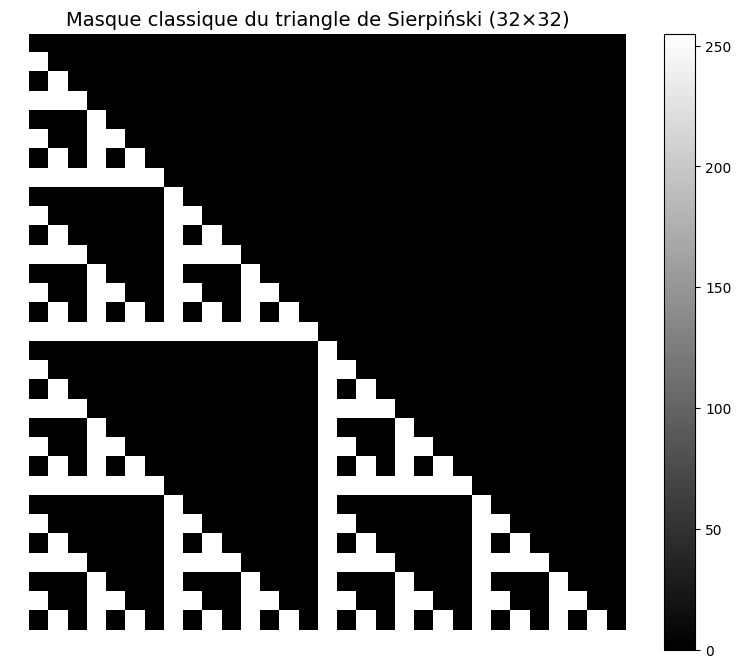

In [8]:
def sierpinski_triangle_mask(size=32):
    """Return a binary mask (size x size) for the Sierpiński triangle."""
    mask = np.zeros((size, size), dtype=int)
    for row in range(size):
        for col in range(size):
            if col <= row and (row & col) == col:
                mask[row, col] = 1
    return mask


size = 32
mask = sierpinski_triangle_mask(size)
display_image(mask * 255, f"Masque classique du triangle de Sierpiński ({size}×{size})", cmap='gray')

**Objectif : Avec un seul circuit, reconstruire :**
- Image normale
- Image inversée
  
![Triangle de Sierpiński](images/fractal.png)

In [ ]:
# todo